In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("soumikrakshit/nyu-depth-v2")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/nyu-depth-v2


# Depth Anything V2

Using device: cuda
Path to dataset files: /kaggle/input/nyu-depth-v2
Dataset sizes - Train: 10000, Val: 1000, Test: 507


Number of trainable parameters: 2,929,281
Epoch 1/10


Validation: 100%|██████████| 125/125 [00:11<00:00, 11.30it/s, loss=0.0798]


Train Loss: 0.1333, Val Loss: 0.0951
Model saved at epoch 1
Epoch 2/10


Validation: 100%|██████████| 125/125 [00:11<00:00, 11.29it/s, loss=0.0736]


...

Train Loss: 0.0858, Val Loss: 0.0749
Model saved at epoch 9
Epoch 10/10


Validation: 100%|██████████| 125/125 [00:11<00:00, 11.30it/s, loss=0.0644]


Train Loss: 0.0856, Val Loss: 0.0758
Evaluating on test set...


Validation: 100%|██████████| 64/64 [00:05<00:00, 12.14it/s, loss=0.0636]


Test Loss: 0.0793
Generating detailed visualizations...

Average Metrics:
Mean Absolute Relative Error: 0.2324
Root Mean Square Error: 0.0774
Threshold Accuracy (δ < 1.25): 0.6498


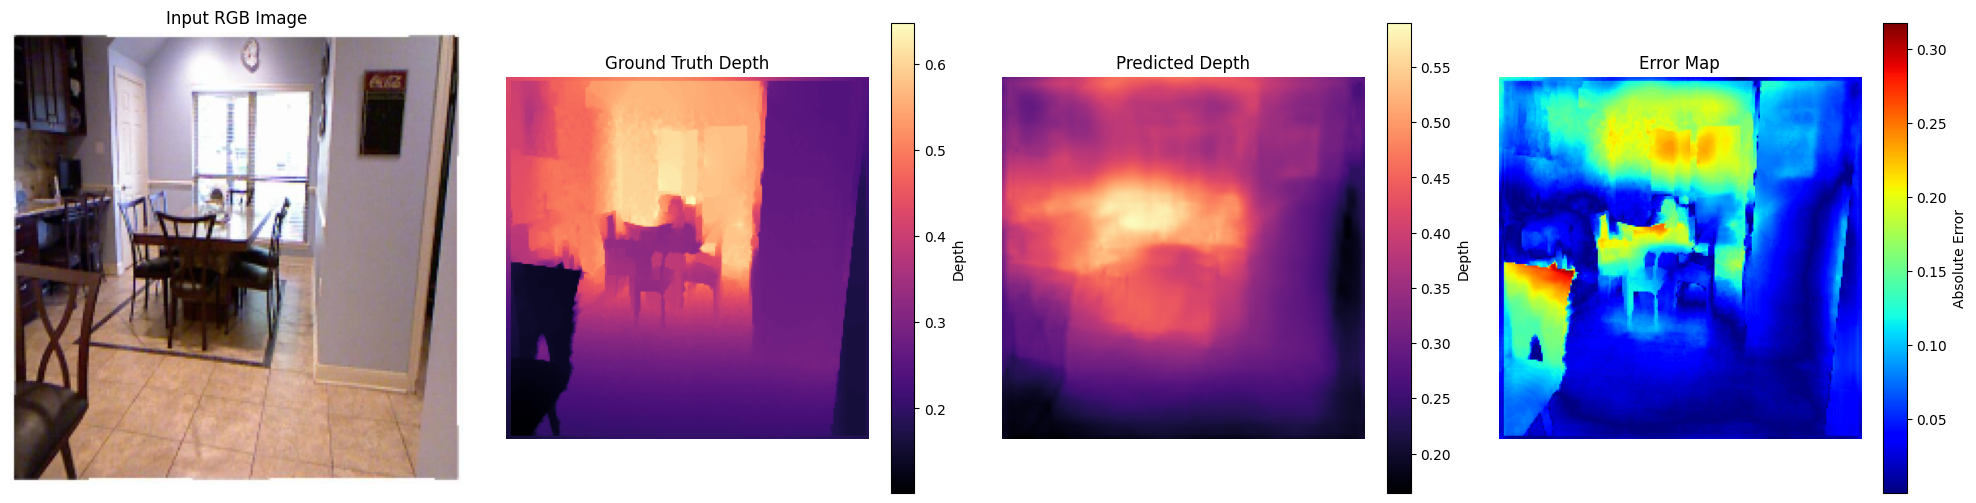

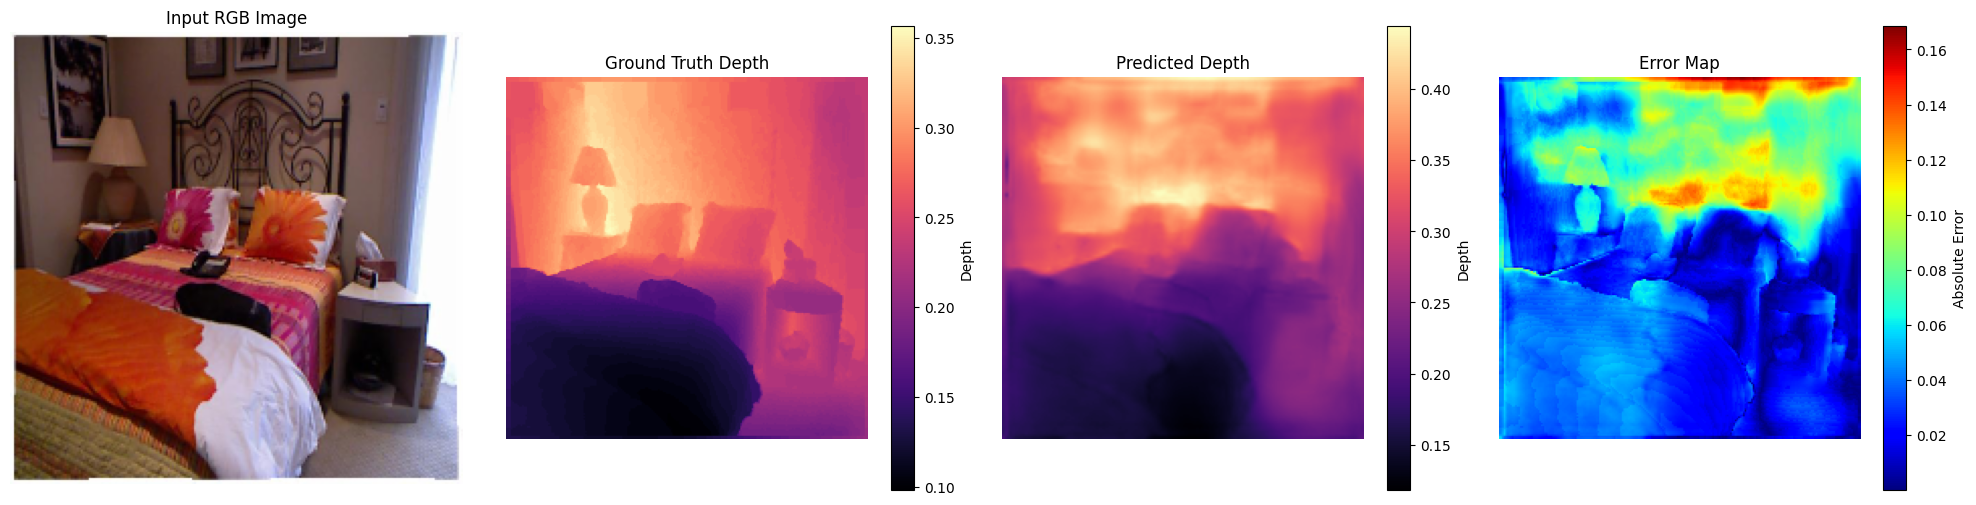

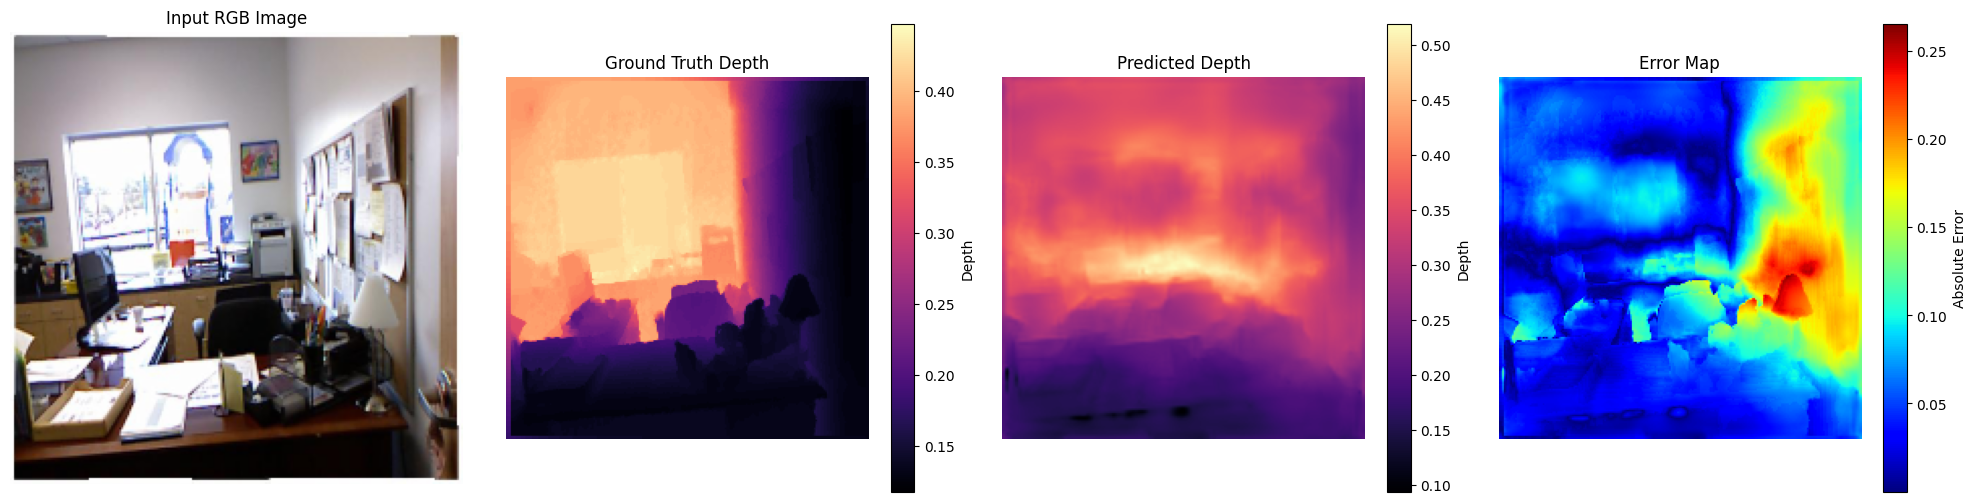

In [56]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import cv2 as cv
import albumentations as A
from albumentations.pytorch import ToTensorV2
import pandas as pd
import numpy as np
from pathlib import Path
import kagglehub
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import timm
from torchvision.models.feature_extraction import create_feature_extractor

# Dataset class
class Dataset:
    def __init__(self, df, tfms):
        self.df = df
        self.tfms = tfms

    def open_im(self, p, gray=False):
        im = cv.imread(str(p))
        im = cv.cvtColor(im, cv.COLOR_BGR2GRAY if gray else cv.COLOR_BGR2RGB)
        return im

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        s = self.df.iloc[idx, :]
        im, dp = s[0], s[1]
        im, dp = self.open_im(im), self.open_im(dp, True)
        augs = self.tfms(image=im, mask=dp)
        im, dp = augs['image'], augs['mask'] / 255.
        return im, dp.unsqueeze(0)

# Create a custom DepthAnything model architecture inspired by Depth Anything v2
class DepthAnythingCustom(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        # Use a pretrained encoder backbone (DenseNet or EfficientNet)
        self.encoder = timm.create_model('efficientnet_b0', features_only=True, pretrained=pretrained)

        # Get feature dimensions
        dummy_input = torch.randn(1, 3, 224, 224)
        features = self.encoder(dummy_input)
        feature_dims = [f.shape[1] for f in features]

        # Decoder with skip connections (FPN-like architecture)
        self.decoder = nn.ModuleDict()
        prev_dim = feature_dims[-1]

        # Top-down path with lateral connections
        for i in range(len(feature_dims)-2, -1, -1):
            # Lateral connection
            self.decoder[f'lateral_{i}'] = nn.Conv2d(feature_dims[i], 256, kernel_size=1)

            # Top-down connection
            self.decoder[f'top_down_{i}'] = nn.Sequential(
                nn.Conv2d(prev_dim, 256, kernel_size=3, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True)
            )

            # Update previous dimension
            prev_dim = 256

        # Final depth prediction head
        self.depth_head = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def trainable_encoder(self, trainable=True):
        # Enable or disable training for encoder parameters
        for param in self.encoder.parameters():
            param.requires_grad = trainable

    def forward(self, x):
        # Get features from encoder
        features = self.encoder(x)

        # Top-down pathway with lateral connections (like FPN)
        prev_feature = features[-1]
        outputs = []

        for i in range(len(features)-2, -1, -1):
            # Get lateral feature
            lateral = self.decoder[f'lateral_{i}'](features[i])

            # Upsample previous feature
            top_down = nn.functional.interpolate(
                prev_feature, size=lateral.shape[2:], mode='bilinear', align_corners=False
            )

            # Apply convolution
            top_down = self.decoder[f'top_down_{i}'](top_down)

            # Combine lateral and top-down
            prev_feature = lateral + top_down
            outputs.append(prev_feature)

        # Use the final feature map for depth prediction
        final_feature = outputs[-1]

        # Apply depth head
        depth_pred = self.depth_head(final_feature)

        # Upsample to input size if needed
        if depth_pred.shape[2:] != x.shape[2:]:
            depth_pred = nn.functional.interpolate(
                depth_pred, size=x.shape[2:], mode='bilinear', align_corners=False
            )

        return depth_pred

    def _num_params(self):
        return sum([p.numel() for p in self.parameters() if p.requires_grad])

# Loss functions
class DepthLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1_loss = nn.L1Loss()

    def forward(self, pred, target):
        # L1 loss
        l1_loss = self.l1_loss(pred, target)

        # SSIM loss (Structural Similarity Index)
        ssim_loss = 1 - ssim(pred, target)

        # Edge loss
        edge_loss = edge_loss_fn(pred, target)

        # Combined loss
        loss = 0.5 * l1_loss + 0.3 * ssim_loss + 0.2 * edge_loss

        return loss

# Helper functions for loss calculation
def gaussian_kernel(size=11, sigma=1.5):
    """Generate a Gaussian kernel for SSIM calculation"""
    x = torch.arange(-(size // 2), size // 2 + 1, dtype=torch.float32)
    x = x.view(1, -1).repeat(size, 1)
    y = x.t()
    kernel = torch.exp(-(x ** 2 + y ** 2) / (2 * sigma ** 2))
    return kernel / kernel.sum()

def ssim(pred, target, window_size=11, sigma=1.5):
    """Calculate SSIM between prediction and target"""
    channel = pred.size(1)
    window = gaussian_kernel(window_size, sigma).to(pred.device)
    window = window.expand(channel, 1, window_size, window_size)

    mu1 = torch.nn.functional.conv2d(pred, window, padding=window_size//2, groups=channel)
    mu2 = torch.nn.functional.conv2d(target, window, padding=window_size//2, groups=channel)

    mu1_sq = mu1.pow(2)
    mu2_sq = mu2.pow(2)
    mu1_mu2 = mu1 * mu2

    sigma1_sq = torch.nn.functional.conv2d(pred * pred, window, padding=window_size//2, groups=channel) - mu1_sq
    sigma2_sq = torch.nn.functional.conv2d(target * target, window, padding=window_size//2, groups=channel) - mu2_sq
    sigma12 = torch.nn.functional.conv2d(pred * target, window, padding=window_size//2, groups=channel) - mu1_mu2

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    return ssim_map.mean()

def edge_loss_fn(pred, target):
    """Calculate edge-aware loss using Sobel filters"""
    # Sobel filters
    sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3).to(pred.device)
    sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3).to(pred.device)

    # Apply Sobel filters to get gradients
    pred_grad_x = torch.nn.functional.conv2d(pred, sobel_x, padding=1)
    pred_grad_y = torch.nn.functional.conv2d(pred, sobel_y, padding=1)
    target_grad_x = torch.nn.functional.conv2d(target, sobel_x, padding=1)
    target_grad_y = torch.nn.functional.conv2d(target, sobel_y, padding=1)

    # Calculate edge maps
    pred_grad = torch.sqrt(pred_grad_x ** 2 + pred_grad_y ** 2)
    target_grad = torch.sqrt(target_grad_x ** 2 + target_grad_y ** 2)

    # L1 loss on edge maps
    return torch.nn.functional.l1_loss(pred_grad, target_grad)

# Training function
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    with tqdm(train_loader, desc="Training") as pbar:
        for images, depths in pbar:
            images, depths = images.to(device), depths.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            # Resize outputs to match target if needed
            if outputs.shape != depths.shape:
                outputs = torch.nn.functional.interpolate(
                    outputs,
                    size=depths.shape[2:],
                    mode='bilinear',
                    align_corners=False
                )

            loss = criterion(outputs, depths)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss

# Validation function
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        with tqdm(val_loader, desc="Validation") as pbar:
            for images, depths in pbar:
                images, depths = images.to(device), depths.to(device)

                outputs = model(images)

                if outputs.shape != depths.shape:
                    outputs = torch.nn.functional.interpolate(
                        outputs,
                        size=depths.shape[2:],
                        mode='bilinear',
                        align_corners=False
                    )

                loss = criterion(outputs, depths)

                running_loss += loss.item() * images.size(0)
                pbar.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(val_loader.dataset)
    return epoch_loss

# Metrics
def compute_metrics(pred, target):
    """Compute common depth estimation metrics"""
    # Convert to numpy arrays
    pred = pred.cpu().numpy()
    target = target.cpu().numpy()

    # Mask out invalid predictions/targets
    mask = (target > 0)

    # Calculate metrics
    thresh = np.maximum((target / pred), (pred / target))
    a1 = (thresh < 1.25).mean()
    a2 = (thresh < 1.25 ** 2).mean()
    a3 = (thresh < 1.25 ** 3).mean()

    abs_rel = np.mean(np.abs(target - pred) / target)
    sq_rel = np.mean(((target - pred) ** 2) / target)

    rmse = np.sqrt(np.mean((target - pred) ** 2))
    rmse_log = np.sqrt(np.mean((np.log(target) - np.log(pred)) ** 2))

    return {
        'a1': a1,
        'a2': a2,
        'a3': a3,
        'abs_rel': abs_rel,
        'sq_rel': sq_rel,
        'rmse': rmse,
        'rmse_log': rmse_log
    }

# Main training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device, save_path):
    best_loss = float('inf')

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")

        # Train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

        # Validate
        val_loss = validate(model, val_loader, criterion, device)

        # Step scheduler
        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        # Save model if validation loss improved
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, save_path)
            print(f"Model saved at epoch {epoch+1}")

    return model

# Prepare the NYU dataset according to your code
def prepare_nyu_dataset():
    """Prepare NYU Depth V2 dataset following the structure from your code"""
    # Download dataset using kagglehub
    path = kagglehub.dataset_download("soumikrakshit/nyu-depth-v2")
    print("Path to dataset files:", path)

    # Define paths
    train_csv = Path(path) / "nyu_data/data/nyu2_train.csv"
    base_path = Path(path) / "nyu_data"

    # Read CSV and update paths
    df = pd.read_csv(train_csv, header=None)
    df[0] = df[0].map(lambda x: base_path / x)
    df[1] = df[1].map(lambda x: base_path / x)

    # Split into train/val/test sets
    train_df, val_df = train_test_split(df, test_size=0.1, shuffle=True, random_state=42)
    val_df, test_df = train_test_split(val_df, test_size=0.1, shuffle=True, random_state=42)

    # Reset indices
    train_df.reset_index(drop=True, inplace=True)
    val_df.reset_index(drop=True, inplace=True)
    test_df.reset_index(drop=True, inplace=True)

    # Limit sizes as in your code
    train_df = train_df[0:10000]
    val_df = val_df[0:1000]

    return train_df, val_df, test_df

# Visual evaluation function
def visualize_predictions(model, test_loader, device, num_samples=5):
    """Visualize model predictions on test data"""
    import matplotlib.pyplot as plt

    model.eval()
    samples_seen = 0

    with torch.no_grad():
        for images, depths in test_loader:
            if samples_seen >= num_samples:
                break

            images, depths = images.to(device), depths.to(device)
            outputs = model(images)

            # Process batch
            for i in range(min(images.size(0), num_samples - samples_seen)):
                plt.figure(figsize=(15, 5))

                # Original RGB image
                plt.subplot(1, 3, 1)
                img = images[i].cpu().numpy().transpose(1, 2, 0)
                # Denormalize
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                plt.imshow(img)
                plt.title("Input RGB Image")
                plt.axis('off')

                # Ground truth depth
                plt.subplot(1, 3, 2)
                depth_gt = depths[i, 0].cpu().numpy()
                plt.imshow(depth_gt, cmap='magma')
                plt.title("Ground Truth Depth")
                plt.axis('off')

                # Predicted depth
                plt.subplot(1, 3, 3)
                depth_pred = outputs[i, 0].cpu().numpy()
                plt.imshow(depth_pred, cmap='magma')
                plt.title("Predicted Depth")
                plt.axis('off')

                plt.tight_layout()
                plt.savefig(f"depth_prediction_{samples_seen+1}.png")
                plt.close()

                samples_seen += 1

# Setup and train
def main(batch_size=16, num_epochs=10, learning_rate=1e-3):
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Prepare dataset
    train_df, val_df, test_df = prepare_nyu_dataset()

    # Data transforms
    sample_tfms = [
        A.HorizontalFlip(),
        A.GaussNoise(p=0.2),
        A.OneOf([
            A.MotionBlur(p=.3),
            A.MedianBlur(blur_limit=3, p=0.3),
            A.Blur(blur_limit=3, p=0.5),
        ], p=0.3),
        A.RGBShift(),
        A.RandomBrightnessContrast(),
        A.RandomResizedCrop(size=(384, 384)),
        A.ColorJitter(),
        A.Affine(translate_percent=(-0.1, 0.1), scale=(0.7, 1.3), rotate=(-45, 45), p=0.5),
        A.HueSaturationValue(p=0.3),
    ]

    train_tfms = A.Compose([
        *sample_tfms,
        A.Resize(224, 224),
        A.Normalize(),
        ToTensorV2()
    ])

    valid_tfms = A.Compose([
        A.Resize(224, 224),
        A.Normalize(),
        ToTensorV2()
    ])

    # Create datasets
    train_ds = Dataset(train_df, train_tfms)
    val_ds = Dataset(val_df, valid_tfms)
    test_ds = Dataset(test_df, valid_tfms)

    print(f"Dataset sizes - Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

    # Create dataloaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    # Create model
    model = DepthAnythingCustom(pretrained=True)
    model.to(device)

    # Freeze encoder weights initially
    model.trainable_encoder(False)

    # Print model parameters
    print(f"Number of trainable parameters: {model._num_params():,}")

    # Loss function
    criterion = DepthLoss()

    # Optimizer
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)

    # Learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    # Train model
    save_path = "depth_anything_custom_nyu.pth"
    trained_model = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        scheduler,
        num_epochs,
        device,
        save_path
    )

    # Evaluate on test set
    print("Evaluating on test set...")
    test_loss = validate(trained_model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}")

    # Visualize some predictions
    # visualize_predictions(trained_model, test_loader, device)

    print("Generating detailed visualizations...")
    visualize_depth_predictions(
        model=model,
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2),
        device=device,
        save_dir='depth_visualization_results',
        num_samples=10
    )

    # For interactive notebooks
    visualize_depth_in_notebook(model, test_loader, device)

    return trained_model

if __name__ == "__main__":
    main(batch_size=8)  # Reduced batch size for memory considerations

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
import cv2
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
from mpl_toolkits.axes_grid1 import make_axes_locatable

def visualize_depth_predictions(model, test_loader, device, save_dir='depth_viz', num_samples=10, cmap='magma'):
    """
    Visualize and evaluate depth predictions from model

    Args:
        model: Trained depth estimation model
        test_loader: DataLoader for test dataset
        device: Device to run model on (cuda/cpu)
        save_dir: Directory to save visualizations
        num_samples: Number of samples to visualize
        cmap: Colormap for depth visualization
    """
    # Create save directory
    save_path = Path(save_dir)
    save_path.mkdir(exist_ok=True, parents=True)

    # Set model to evaluation mode
    model.eval()

    # Metrics storage
    metrics = {
        'abs_rel': [],
        'rmse': [],
        'a1': [],  # Threshold accuracy (delta < 1.25)
    }

    # Storage for summary visualization
    summary_images = []
    summary_gt = []
    summary_pred = []
    summary_errors = []

    # Process test samples
    sample_count = 0
    with torch.no_grad():
        for batch_idx, (images, target_depths) in enumerate(test_loader):
            # Move data to device
            images = images.to(device)
            target_depths = target_depths.to(device)

            # Get model predictions
            pred_depths = model(images)

            # Ensure predictions match target size
            if pred_depths.shape != target_depths.shape:
                pred_depths = torch.nn.functional.interpolate(
                    pred_depths,
                    size=target_depths.shape[2:],
                    mode='bilinear',
                    align_corners=False
                )

            # Process each image in batch
            for i in range(images.size(0)):
                if sample_count >= num_samples:
                    break

                # Get individual tensors
                image = images[i].cpu()
                target_depth = target_depths[i, 0].cpu().numpy()
                pred_depth = pred_depths[i, 0].cpu().numpy()

                # Denormalize RGB image for visualization
                img_np = image.numpy().transpose(1, 2, 0)
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img_np = std * img_np + mean
                img_np = np.clip(img_np, 0, 1)

                # Calculate error metrics for this sample
                mask = (target_depth > 0)  # Valid depth mask

                # Error map (absolute difference)
                error_map = np.abs(target_depth - pred_depth)

                # Threshold accuracy
                thresh = np.maximum((target_depth / pred_depth), (pred_depth / target_depth))
                a1 = (thresh < 1.25).mean()

                # Other metrics
                abs_rel = np.mean(np.abs(target_depth - pred_depth) / (target_depth + 1e-6))
                rmse = np.sqrt(np.mean((target_depth - pred_depth) ** 2))

                # Store metrics
                metrics['abs_rel'].append(abs_rel)
                metrics['rmse'].append(rmse)
                metrics['a1'].append(a1)

                # Store for summary visualization
                if len(summary_images) < 5:  # Limit to 5 samples for summary
                    summary_images.append(img_np)
                    summary_gt.append(target_depth)
                    summary_pred.append(pred_depth)
                    summary_errors.append(error_map)

                # Create individual visualizations
                plt.figure(figsize=(20, 10))

                # Input image
                plt.subplot(2, 3, 1)
                plt.imshow(img_np)
                plt.title("Input RGB Image")
                plt.axis('off')

                # Ground truth depth
                plt.subplot(2, 3, 2)
                plt.imshow(target_depth, cmap=cmap)
                plt.colorbar(label='Depth')
                plt.title("Ground Truth Depth")
                plt.axis('off')

                # Predicted depth
                plt.subplot(2, 3, 3)
                plt.imshow(pred_depth, cmap=cmap)
                plt.colorbar(label='Depth')
                plt.title("Predicted Depth")
                plt.axis('off')

                # Error map
                error_plot = plt.subplot(2, 3, 4)
                im = plt.imshow(error_map, cmap='jet')
                divider = make_axes_locatable(error_plot)
                cax = divider.append_axes("right", size="5%", pad=0.05)
                plt.colorbar(im, cax=cax, label='Absolute Error')
                plt.title(f"Error Map (MAE: {abs_rel:.4f})")
                plt.axis('off')

                # Depth histogram
                plt.subplot(2, 3, 5)
                plt.hist(target_depth.flatten(), bins=50, alpha=0.5, label="Ground Truth")
                plt.hist(pred_depth.flatten(), bins=50, alpha=0.5, label="Prediction")
                plt.legend()
                plt.title("Depth Distribution")
                plt.xlabel("Depth")
                plt.ylabel("Frequency")

                # Scatter plot: GT vs Pred
                plt.subplot(2, 3, 6)
                # Sample points to avoid overcrowding
                sample_mask = np.random.choice(target_depth.size, 1000, replace=False)
                plt.scatter(
                    target_depth.flatten()[sample_mask],
                    pred_depth.flatten()[sample_mask],
                    alpha=0.5, s=1
                )
                max_val = max(target_depth.max(), pred_depth.max())
                plt.plot([0, max_val], [0, max_val], 'r-', alpha=0.7)  # Perfect prediction line
                plt.xlabel("Ground Truth Depth")
                plt.ylabel("Predicted Depth")
                plt.title(f"GT vs Pred (RMSE: {rmse:.4f}, Acc: {a1:.4f})")

                plt.tight_layout()
                plt.savefig(save_path / f"depth_prediction_{sample_count+1}.png", dpi=150)
                plt.close()

                sample_count += 1

            if sample_count >= num_samples:
                break

    # Generate summary visualization with all samples in a grid
    if summary_images:
        create_summary_visualization(summary_images, summary_gt, summary_pred, summary_errors,
                                    save_path / "depth_prediction_summary.png", cmap)

    # Print average metrics
    print("\nAverage Metrics:")
    print(f"Mean Absolute Relative Error: {np.mean(metrics['abs_rel']):.4f}")
    print(f"Root Mean Square Error: {np.mean(metrics['rmse']):.4f}")
    print(f"Threshold Accuracy (δ < 1.25): {np.mean(metrics['a1']):.4f}")

    # Generate metrics visualization
    visualize_metrics(metrics, save_path / "metrics_summary.png")

    return metrics

def create_summary_visualization(images, gt_depths, pred_depths, error_maps, save_path, cmap='magma'):
    """Create a summary visualization with multiple samples in a grid"""
    n_samples = len(images)

    plt.figure(figsize=(16, 4*n_samples))

    for i in range(n_samples):
        # Input RGB
        plt.subplot(n_samples, 4, i*4 + 1)
        plt.imshow(images[i])
        plt.title("Input" if i == 0 else "")
        plt.axis('off')

        # Ground truth depth
        plt.subplot(n_samples, 4, i*4 + 2)
        plt.imshow(gt_depths[i], cmap=cmap)
        plt.title("Ground Truth" if i == 0 else "")
        plt.axis('off')

        # Predicted depth
        plt.subplot(n_samples, 4, i*4 + 3)
        plt.imshow(pred_depths[i], cmap=cmap)
        plt.title("Prediction" if i == 0 else "")
        plt.axis('off')

        # Error map
        plt.subplot(n_samples, 4, i*4 + 4)
        plt.imshow(error_maps[i], cmap='jet')
        plt.title("Error Map" if i == 0 else "")
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.close()

def visualize_metrics(metrics, save_path):
    """Visualize metrics distributions"""
    plt.figure(figsize=(15, 5))

    # Absolute Relative Error
    plt.subplot(1, 3, 1)
    sns.histplot(metrics['abs_rel'], kde=True)
    plt.axvline(np.mean(metrics['abs_rel']), color='r', linestyle='--',
                label=f'Mean: {np.mean(metrics["abs_rel"]):.4f}')
    plt.title('Absolute Relative Error')
    plt.legend()

    # RMSE
    plt.subplot(1, 3, 2)
    sns.histplot(metrics['rmse'], kde=True)
    plt.axvline(np.mean(metrics['rmse']), color='r', linestyle='--',
                label=f'Mean: {np.mean(metrics["rmse"]):.4f}')
    plt.title('Root Mean Square Error')
    plt.legend()

    # Threshold Accuracy
    plt.subplot(1, 3, 3)
    sns.histplot(metrics['a1'], kde=True)
    plt.axvline(np.mean(metrics['a1']), color='r', linestyle='--',
                label=f'Mean: {np.mean(metrics["a1"]):.4f}')
    plt.title('Threshold Accuracy (δ < 1.25)')
    plt.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()

def create_depth_colormap():
    """Create a custom colormap for depth visualization"""
    # Define custom color map (viridis-like but with better depth perception)
    colors = [
        (0, 0, 0),       # Black for closest depths
        (0, 0, 0.5),     # Dark blue
        (0, 0.5, 1),     # Light blue
        (0, 0.8, 0.3),   # Green-blue
        (1, 1, 0),       # Yellow
        (1, 0, 0),       # Red
        (1, 1, 1)        # White for furthest depths
    ]

    cmap = LinearSegmentedColormap.from_list('depth_cmap', colors)
    return cmap

def create_cross_section_plot(image, gt_depth, pred_depth, save_path=None):
    """Create a cross-section plot showing depth along horizontal and vertical lines"""
    h, w = gt_depth.shape

    # Get middle row and column
    mid_row = gt_depth[h//2, :]
    mid_col = gt_depth[:, w//2]

    pred_mid_row = pred_depth[h//2, :]
    pred_mid_col = pred_depth[:, w//2]

    plt.figure(figsize=(18, 10))

    # Show image with cross-section lines
    plt.subplot(2, 2, 1)
    plt.imshow(image)
    plt.axhline(h//2, color='r', linestyle='--', alpha=0.7)
    plt.axvline(w//2, color='g', linestyle='--', alpha=0.7)
    plt.title("Cross-sections")
    plt.axis('off')

    # Show depth map
    plt.subplot(2, 2, 2)
    plt.imshow(gt_depth, cmap='magma')
    plt.axhline(h//2, color='r', linestyle='--', alpha=0.7)
    plt.axvline(w//2, color='g', linestyle='--', alpha=0.7)
    plt.title("Ground Truth Depth")
    plt.axis('off')

    # Plot horizontal cross-section
    plt.subplot(2, 2, 3)
    plt.plot(range(w), mid_row, 'r-', label='Ground Truth')
    plt.plot(range(w), pred_mid_row, 'b--', label='Prediction')
    plt.title("Horizontal Cross-section")
    plt.xlabel("X Position")
    plt.ylabel("Depth")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot vertical cross-section
    plt.subplot(2, 2, 4)
    plt.plot(mid_col, range(h), 'r-', label='Ground Truth')
    plt.plot(pred_mid_col, range(h), 'b--', label='Prediction')
    plt.title("Vertical Cross-section")
    plt.xlabel("Depth")
    plt.ylabel("Y Position")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.close()

def visualize_3d_point_cloud(rgb_image, depth_map, save_path=None, subsample=5):
    """Create a 3D point cloud visualization from RGB image and depth map"""
    try:
        from mpl_toolkits.mplot3d import Axes3D
    except ImportError:
        print("3D plotting requires mpl_toolkits.mplot3d")
        return

    # Create coordinate grid
    h, w = depth_map.shape
    xx, yy = np.meshgrid(range(0, w, subsample), range(0, h, subsample))

    # Get corresponding depth values (subsampled)
    z = depth_map[yy, xx]

    # Get corresponding colors (subsampled)
    colors = rgb_image[yy, xx]

    # Create 3D plot
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Plot points
    ax.scatter(xx, yy, z, c=colors.reshape(-1, 3), s=0.1)

    # Set labels
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Depth')
    ax.set_title('3D Point Cloud from Depth Map')

    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.close()

def visualize_depth_in_notebook(model, test_loader, device, num_samples=3):
    """Interactive visualization for Jupyter notebooks"""
    model.eval()

    # Custom depth colormap
    depth_cmap = create_depth_colormap()

    with torch.no_grad():
        for images, target_depths in test_loader:
            # Get batch of images
            images = images.to(device)
            target_depths = target_depths.to(device)

            # Get predictions
            pred_depths = model(images)

            # Ensure same shape
            if pred_depths.shape != target_depths.shape:
                pred_depths = torch.nn.functional.interpolate(
                    pred_depths,
                    size=target_depths.shape[2:],
                    mode='bilinear',
                    align_corners=False
                )

            # Display samples
            for i in range(min(num_samples, images.size(0))):
                # Get numpy arrays
                image = images[i].cpu().numpy().transpose(1, 2, 0)
                target_depth = target_depths[i, 0].cpu().numpy()
                pred_depth = pred_depths[i, 0].cpu().numpy()

                # Denormalize image
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                image = std * image + mean
                image = np.clip(image, 0, 1)

                # Error map
                error_map = np.abs(target_depth - pred_depth)

                # Display
                fig, axes = plt.subplots(1, 4, figsize=(20, 5))

                # Original image
                axes[0].imshow(image)
                axes[0].set_title("Input RGB Image")
                axes[0].axis('off')

                # Ground truth depth
                im1 = axes[1].imshow(target_depth, cmap='magma')
                plt.colorbar(im1, ax=axes[1], label='Depth')
                axes[1].set_title("Ground Truth Depth")
                axes[1].axis('off')

                # Predicted depth
                im2 = axes[2].imshow(pred_depth, cmap='magma')
                plt.colorbar(im2, ax=axes[2], label='Depth')
                axes[2].set_title("Predicted Depth")
                axes[2].axis('off')

                # Error map
                im3 = axes[3].imshow(error_map, cmap='jet')
                plt.colorbar(im3, ax=axes[3], label='Absolute Error')
                axes[3].set_title("Error Map")
                axes[3].axis('off')

                plt.tight_layout()
                plt.show()

                # Create cross-section plot
                create_cross_section_plot(image, target_depth, pred_depth)

                # Try to create 3D visualization if resources allow
                try:
                    visualize_3d_point_cloud(image, pred_depth)
                except Exception as e:
                    print(f"Skipping 3D visualization: {e}")

            # Only process one batch
            break

# # Example usage in your main function
# def main():
#     trained_model = model
#     batch_size = 8

#     train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle=True, num_workers=2)
#     val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
#     test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

#     # After training and evaluation, add:
#     print("Generating detailed visualizations...")
#     visualize_depth_predictions(
#         model=model,
#         train_loader = DataLoader(train_ds, batch_size = batch_size, shuffle=True, num_workers=2),
#         val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2),
#         test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2),
#         device=device,
#         save_dir='depth_visualization_results',
#         num_samples=10
#     )

#     # For interactive notebooks
#     visualize_depth_in_notebook(model, test_loader, device)